## Notebook for visualizing results from sequential implementation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys
import jax.numpy as jnp
import jax
import json
import os

from NRT_functions import losses
from NRT_functions import helper_functions
from NRT_functions import plotters
from sweep_analysis_sequential import generate_2d_plots, generate_loss_plots

In [ ]:
filepath = './data/251205/sweep_111115/run001'
counter = 2
save_fig = 0
plot_scale = 1

if counter == '':
    adding_string = ''
else:
    adding_string = '_'

%cd "$filepath"

# Load parameters
with open('parameters.json', 'r') as json_file:
    parameters = json.load(json_file)

# Load g0 (activity at origin) instead of W
with open('g0' + adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    g0 = pickle.load(pickle_file)

# Load frequencies
with open('om'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    om = pickle.load(pickle_file)

# Load transformation matrix S
with open('S1'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    S1 = pickle.load(pickle_file)

with open('S2'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    S2 = pickle.load(pickle_file)

# Load losses
with open('min_L'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    min_L = pickle.load(pickle_file)

with open('L'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    L = pickle.load(pickle_file)

# Load initial values
with open('g0_init'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    g0_init = pickle.load(pickle_file)

with open('S_init'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    S_init = pickle.load(pickle_file)

# Load final values
try:
    with open('g0_final'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        g0_final = pickle.load(pickle_file)
except:
    g0_final = g0

try:
    with open('S1_final'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        S1_final = pickle.load(pickle_file)
    with open('S2_final'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        S2_final = pickle.load(pickle_file)
except:
    S1_final = S1
    S2_final = S2

# Use final values if min loss is poor
# if min_L[0] < 1:
g0 = g0_final
S1 = S1_final
S2 = S2_final

# Compute D from g0 shape
D = g0.shape[0]
M = int((D - 1) / 2)

In [ ]:
# Visualize 2D plane results using generate_2d_plots from sweep_analysis_sequential
if parameters["dim"] == 2:
    # Get current directory for savepath
    savepath = os.getcwd()
    
    # Generate all 2D plots using the imported function
    figures = generate_2d_plots(g0, om, S1, S2, parameters, savepath, counter, plot_scale)
    
    # Display the figures
    for fig_name, fig in figures.items():
        plt.figure(fig.number)
        plt.show()
    
    # Calculate overall loss for summary
    N_plot = 70
    if parameters["sampling_choice"] == 1:
        phi_calc = np.random.normal(0, 1, [N_plot*N_plot, 2])
    elif parameters['sampling_choice'] == 0 or parameters['sampling_choice'] == 2:
        r = np.sqrt(np.random.uniform(size=[N_plot*N_plot, 1]))
        theta = np.random.uniform(size=[N_plot*N_plot, 1]) * 2 * np.pi
        phi_calc = np.hstack([r * np.cos(theta), r * np.sin(theta)])
    else:
        phi_calc_small = np.linspace(-np.pi, np.pi, N_plot)/2
        phi_calc_small = np.meshgrid(phi_calc_small, phi_calc_small)
        phi_calc = np.hstack([np.ndarray.flatten(phi_calc_small[0])[:,None], 
                              np.ndarray.flatten(phi_calc_small[1])[:,None]])
    
    sigma_sq = parameters.get("sigma_sq", 0.04)
    sigma_theta = parameters.get("sigma_theta", 0.5)
    f = parameters.get("f", 1)
    chi = helper_functions.calc_chi_plane(phi_calc, sigma_theta, f)
    overall_loss = losses.sep_plane_KernChi_seq(g0, om, S1, S2, phi_calc, sigma_sq, chi)
    
    print(f"Overall separation loss: {overall_loss:.5f}")

In [ ]:
# Plot the loss curves using generate_loss_plots from sweep_analysis_sequential
# Load lambda arrays if they exist
try:
    with open('lambda_pos' + adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        lambda_pos = pickle.load(pickle_file)
except:
    lambda_pos = None

try:
    with open('lambda_norm' + adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        lambda_norm = pickle.load(pickle_file)
except:
    lambda_norm = None

fig_loss = generate_loss_plots(L, min_L, lambda_pos, lambda_norm)
plt.show()

100%|██████████| 65/65 [00:20<00:00,  3.19it/s]


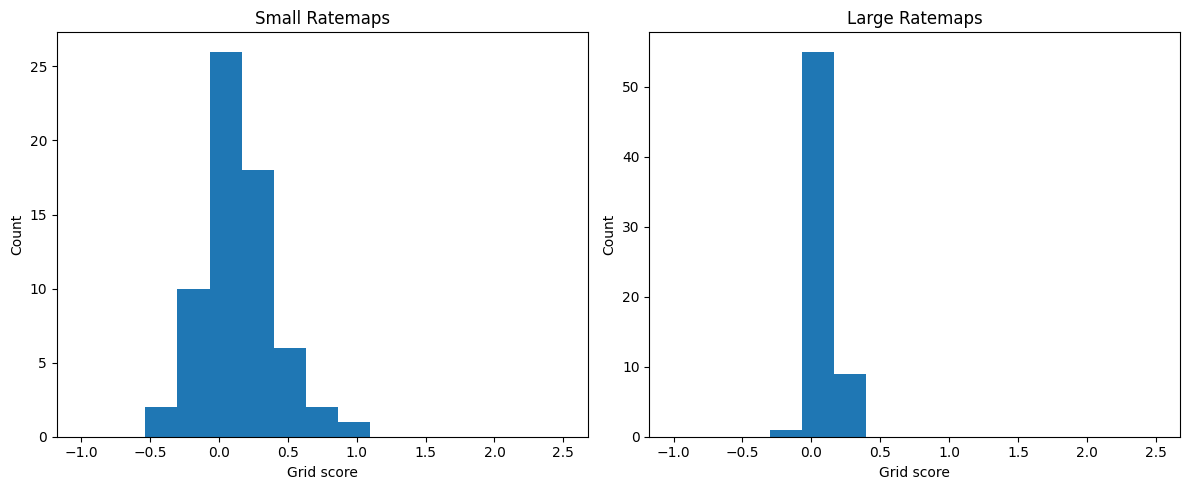

In [ ]:
from NRT_functions.analysis import quantitative_analysis_seq

fig_score = quantitative_analysis_seq(g0, S1, S2, om, parameters, counter, savepath=os.getcwd())

In [ ]:
# Analyze S matrix structure
print("\nAnalysis of S (change of basis matrix):")
print(f"  Shape: {S.shape}")
print(f"  Frobenius norm: {np.linalg.norm(S):.5f}")
print(f"  Condition number: {np.linalg.cond(S):.5f}")
print(f"  Determinant: {np.linalg.det(S):.5f}")

# Note: S matrix visualization is generated by generate_2d_plots() above